<a href="https://colab.research.google.com/github/mohamedsaif21/NM_saif_DS/blob/mohamedsaif21-patch-1/Copy_of_AI_Driven_Stock_Price_Prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Implementation file**

stock-price-prediction/
├── data/
│   └── AAPL.csv  ← downloaded dataset
├── model/
│   └── lstm_stock_model.h5  ← saved trained model
├── stock_predictor.ipynb    ← Jupyter notebook for training
└── app.py                   ← Streamlit web app (optional)


In [ ]:
import pandas as pd

# Load your CSV file
df = pd.read_csv("Apple Dataset.csv")  # Update filename as needed
print(df.head())
print(df.columns)

         Date      Open      High       Low     Close  Adj Close     Volume
0  1980-12-12  0.128348  0.128906  0.128348  0.128348   0.099058  469033600
1  1980-12-15  0.122210  0.122210  0.121652  0.121652   0.093890  175884800
2  1980-12-16  0.113281  0.113281  0.112723  0.112723   0.086999  105728000
3  1980-12-17  0.115513  0.116071  0.115513  0.115513   0.089152   86441600
4  1980-12-18  0.118862  0.119420  0.118862  0.118862   0.091737   73449600
Index(['Date', 'Open', 'High', 'Low', 'Close', 'Adj Close', 'Volume'], dtype='object')


Preprocessing & Normalization

In [ ]:
import numpy as np
from sklearn.preprocessing import MinMaxScaler

# Use only the 'Close' column
data = df[['Close']].values

# Normalize
scaler = MinMaxScaler()
scaled_data = scaler.fit_transform(data)

# Create sequences
def create_sequences(data, sequence_length):
    X, y = [], []
    for i in range(sequence_length, len(data)):
        X.append(data[i-sequence_length:i])
        y.append(data[i])
    return np.array(X), np.array(y)

sequence_length = 60
X, y = create_sequences(scaled_data, sequence_length)

# Train-test split
split = int(0.8 * len(X))
X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]

# Reshape for LSTM
X_train = X_train.reshape((X_train.shape[0], X_train.shape[1], 1))
X_test = X_test.reshape((X_test.shape[0], X_test.shape[1], 1))

 Build and Train LSTM Model

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout

model = Sequential([
    LSTM(50, return_sequences=True, input_shape=(X_train.shape[1], 1)),
    Dropout(0.2),
    LSTM(50),
    Dropout(0.2),
    Dense(1)
])

model.compile(optimizer='adam', loss='mean_squared_error')
model.fit(X_train, y_train, epochs=20, batch_size=32, validation_data=(X_test, y_test))

Epoch 1/20


/usr/local/lib/python3.11/dist-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


273/273 ━━━━━━━━━━━━━━━━━━━━ 11s 34ms/step - loss: 1.4888e-04 - val_loss: 0.0057
Epoch 2/20
273/273 ━━━━━━━━━━━━━━━━━━━━ 9s 32ms/step - loss: 2.0405e-05 - val_loss: 0.0019
Epoch 3/20
273/273 ━━━━━━━━━━━━━━━━━━━━ 9s 33ms/step - loss: 1.4847e-05 - val_loss: 6.8302e-04
Epoch 4/20
273/273 ━━━━━━━━━━━━━━━━━━━━ 9s 34ms/step - loss: 1.5058e-05 - val_loss: 0.0029
Epoch 5/20
273/273 ━━━━━━━━━━━━━━━━━━━━ 9s 30ms/step - loss: 1.5633e-05 - val_loss: 0.0021
Epoch 6/20
273/273 ━━━━━━━━━━━━━━━━━━━━ 10s 30ms/step - loss: 1.5764e-05 - val_loss: 0.0031
Epoch 7/20
273/273 ━━━━━━━━━━━━━━━━━━━━ 11s 32ms/step - loss: 1.4503e-05 - val_loss: 0.0044
Epoch 8/20
273/273 ━━━━━━━━━━━━━━━━━━━━ 10s 32ms/step - loss: 1.3796e-05 - val_loss: 0.0024
Epoch 9/20
273/273 ━━━━━━━━━━━━━━━━━━━━ 10s 38ms/step - loss: 1.4618e-05 - val_loss: 8.0762e-04
Epoch 10/20
273/273 ━━━━━━━━━━━━━━━━━━━━ 9s 32ms/step - loss: 1.8402e-05 - val_loss: 0.0021
Epoch 11/20
273/273 ━━━━━━━━━━━━━━━━━━━━ 9s 32ms/step - loss: 1.4237e-05 - val_loss: 0.

 Evaluate and Visualize Predictions

69/69 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step


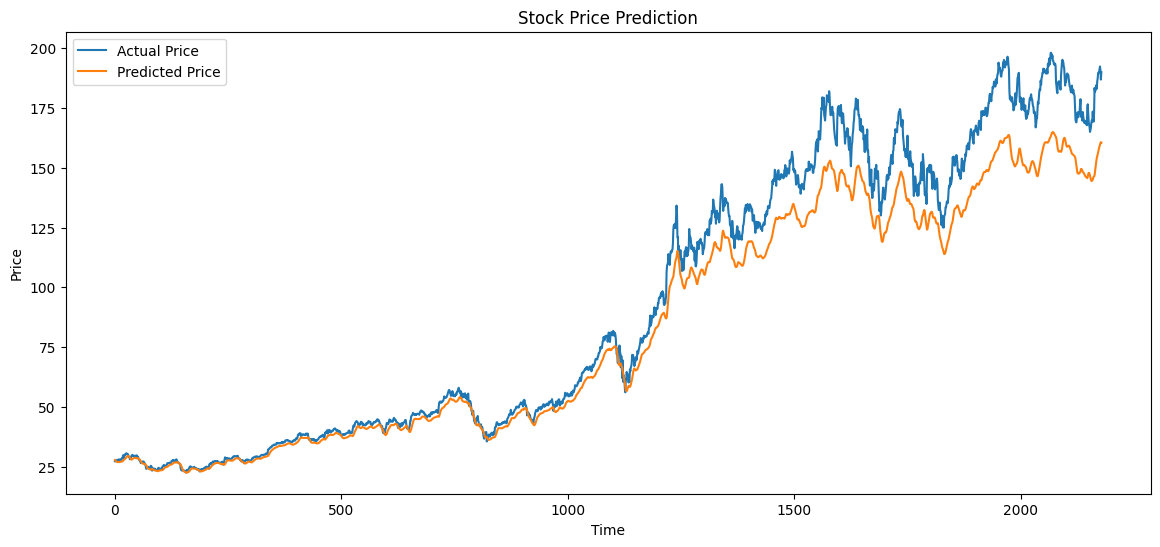

In [ ]:
import matplotlib.pyplot as plt

predicted = model.predict(X_test)
predicted = scaler.inverse_transform(predicted)
y_test_scaled = scaler.inverse_transform(y_test.reshape(-1, 1))

plt.figure(figsize=(14,6))
plt.plot(y_test_scaled, label='Actual Price')
plt.plot(predicted, label='Predicted Price')
plt.title('Stock Price Prediction')
plt.xlabel('Time')
plt.ylabel('Price')
plt.legend()
plt.show()


In [ ]:
model.save('lstm_stock_model.keras')
